# Verifying `ccisi_data_gen.py` is Ts-equivalent

**Claim.** The 0.5 ms version of `ccisi_data_gen.py` (under `diff_rate_test/2000_rate/ccisi/`)
produces spike trains that represent the *same continuous-time process* as the
1 ms version. Concretely:

1. Same total spike count for the same `(firing_rate, isi)` — driven by
   `num_pairs = round(firing_rate * duration_sec)` which is Ts-invariant.
2. Just **more zero bins**: shape (20, 2000) at Ts=0.5 ms vs (20, 1000) at
   Ts=1 ms, but the nonzero count is the same.
3. Same **cross-channel** ISI structure in real time — for each pair
   `(neuron_a, neuron_b)`, the lag from an a-spike to its matching b-spike is
   `isi` ms (= `isi` bins at Ts=1 ms, `2 * isi` bins at Ts=0.5 ms).

This notebook tests all three claims and includes a stress test at high
density (where placement saturation matters). This is the CCISI counterpart
to `isi_data_generation.ipynb`; the key adaptation is that ISIs cross channel
boundaries (even-indexed `neuron_a` leads, odd-indexed `neuron_b` follows).

**Note on randomness.** Even with the same `np.random.seed`, the two
implementations call `np.random.randint(0, time_steps - isi_steps)` with
different upper bounds (990 vs 1980), so the *exact spike positions* differ
between Ts. We verify the *invariants*, not bit-for-bit equality.

## 1. Setup: load both `ccisi_data_gen.py` modules

In [1]:
import importlib.util
import os
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = r'd:\IC_2025\IRP\workspace\my_project'

def _load(name: str, rel_path: str):
    """Load a Python file as a uniquely-named module so the two `ccisi_data_gen.py`
    files don't collide in `sys.modules`."""
    spec = importlib.util.spec_from_file_location(name, os.path.join(PROJECT_ROOT, rel_path))
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

ccisi_1ms  = _load('ccisi_data_gen_1ms',  'code/synthetic/ccisi/ccisi_data_gen.py')
ccisi_05ms = _load('ccisi_data_gen_05ms', 'code/synthetic/diff_rate_test/2000_rate/ccisi/ccisi_data_gen.py')

print(f'1ms:    TIME_STEPS={ccisi_1ms.TIME_STEPS}, NUM_NEURONS={ccisi_1ms.NUM_NEURONS}, no TS_MS (implicit 1.0)')
print(f'0.5ms:  TIME_STEPS={ccisi_05ms.TIME_STEPS}, NUM_NEURONS={ccisi_05ms.NUM_NEURONS}, TS_MS={ccisi_05ms.TS_MS}')
print(f'Total real-time covered:')
print(f'  1ms:   {ccisi_1ms.TIME_STEPS * 1.0:.0f} ms')
print(f'  0.5ms: {ccisi_05ms.TIME_STEPS * ccisi_05ms.TS_MS:.0f} ms')

1ms:    TIME_STEPS=1000, NUM_NEURONS=20, no TS_MS (implicit 1.0)
0.5ms:  TIME_STEPS=2000, NUM_NEURONS=20, TS_MS=0.5
Total real-time covered:
  1ms:   1000 ms
  0.5ms: 1000 ms


## 2. Test 1: same `(firing_rate, isi)` produces the same spike count

Each neuron should get `num_pairs` spikes (one per CCISI pair placement),
where `num_pairs = round(firing_rate * duration_seconds)`. Both files compute
`duration_seconds = 1.0`, so the expected per-neuron count is the same.

In [2]:
FIRING_RATE = 10   # Hz
ISI         = 20   # ms
NUM_NEURONS = 20   # must be even — pairs (0,1), (2,3), ..., (18,19)

np.random.seed(7)
train_1ms = ccisi_1ms.generate_spike_train(
    firing_rate=FIRING_RATE, isi=ISI,
    num_neurons=NUM_NEURONS, time_steps=1000,
)
np.random.seed(7)
train_05ms = ccisi_05ms.generate_spike_train(
    firing_rate=FIRING_RATE, isi=ISI,
    num_neurons=NUM_NEURONS, time_steps=2000, ts_ms=0.5,
)

expected_per_neuron = round(FIRING_RATE * 1.0)   # 1 spike per neuron per pair placement
print(f'Expected per-neuron spike count: {expected_per_neuron}')
print()
print(f'Ts = 1.0 ms:  shape={train_1ms.shape},  total={train_1ms.sum()},  per-neuron={train_1ms.sum(axis=1)}')
print(f'Ts = 0.5 ms:  shape={train_05ms.shape}, total={train_05ms.sum()}, per-neuron={train_05ms.sum(axis=1)}')

assert train_1ms.sum() == train_05ms.sum(), 'total spike counts differ'
assert (train_1ms.sum(axis=1) == train_05ms.sum(axis=1)).all(), 'per-neuron counts differ'
assert (train_1ms.sum(axis=1) == expected_per_neuron).all(), 'per-neuron count not as expected'
print('\nOK: total and per-neuron spike counts are identical and match the formula.')

Expected per-neuron spike count: 10

Ts = 1.0 ms:  shape=(20, 1000),  total=200,  per-neuron=[10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10]
Ts = 0.5 ms:  shape=(20, 2000), total=200, per-neuron=[10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10]

OK: total and per-neuron spike counts are identical and match the formula.


## 3. Test 2: more zero bins

Same number of nonzero entries, but the 0.5 ms array is twice as wide,
so the extra width is entirely zeros.

In [3]:
n_bins_1ms  = train_1ms.size
n_bins_05ms = train_05ms.size
nonzero_1ms  = int(train_1ms.sum())
nonzero_05ms = int(train_05ms.sum())

print(f'Ts = 1.0 ms:  total bins = {n_bins_1ms:>6d}, nonzero = {nonzero_1ms:>4d}, '
      f'sparsity = {nonzero_1ms/n_bins_1ms:.4f}')
print(f'Ts = 0.5 ms:  total bins = {n_bins_05ms:>6d}, nonzero = {nonzero_05ms:>4d}, '
      f'sparsity = {nonzero_05ms/n_bins_05ms:.4f}')
print()
print(f'Extra zero bins at Ts=0.5: {n_bins_05ms - n_bins_1ms} (= same width 2x)')
print(f'Sparsity ratio: {(nonzero_1ms/n_bins_1ms) / (nonzero_05ms/n_bins_05ms):.2f}'
      f'  (expected ~2.0 — finer sampling = half the density)')

assert n_bins_05ms == 2 * n_bins_1ms
assert nonzero_05ms == nonzero_1ms
print('\nOK: same nonzero count, exactly twice as many bins.')

Ts = 1.0 ms:  total bins =  20000, nonzero =  200, sparsity = 0.0100
Ts = 0.5 ms:  total bins =  40000, nonzero =  200, sparsity = 0.0050

Extra zero bins at Ts=0.5: 20000 (= same width 2x)
Sparsity ratio: 2.00  (expected ~2.0 — finer sampling = half the density)

OK: same nonzero count, exactly twice as many bins.


## 4. Test 3: side-by-side raster plot

Plot both spike trains on the same real-time x-axis. Even rows are
`neuron_a` (leaders, blue) and odd rows are `neuron_b` (followers, red), so
the CCISI pair structure is visible at a glance.

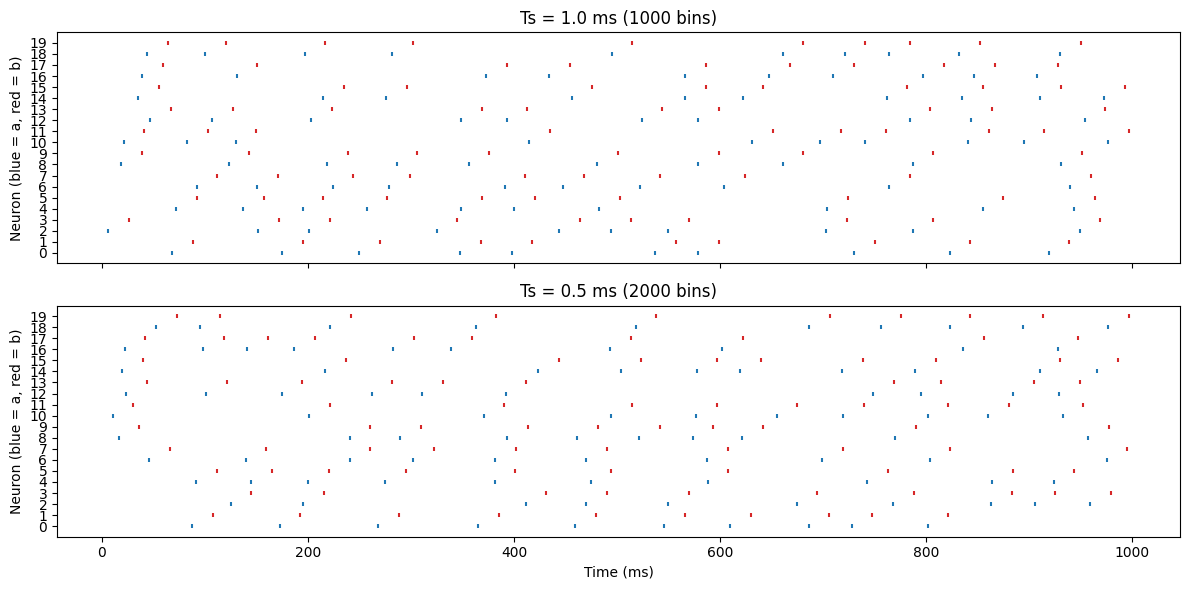

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax, train, ts_ms, label in [
    (axes[0], train_1ms,  1.0, 'Ts = 1.0 ms (1000 bins)'),
    (axes[1], train_05ms, 0.5, 'Ts = 0.5 ms (2000 bins)'),
]:
    for neuron_idx in range(train.shape[0]):
        spike_bins = np.where(train[neuron_idx] > 0)[0]
        spike_times_ms = spike_bins * ts_ms
        color = 'tab:blue' if neuron_idx % 2 == 0 else 'tab:red'
        ax.scatter(spike_times_ms, np.full_like(spike_times_ms, neuron_idx),
                   s=8, marker='|', color=color)
    ax.set_ylabel('Neuron (blue = a, red = b)')
    ax.set_title(label)
    ax.set_yticks(range(train.shape[0]))

axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()

## 5. Test 4: cross-channel ISI structure is preserved

For each pair `(neuron_a, neuron_b)`, compute all positive time differences
between b-spikes and a-spikes (cross-channel diffs). Each successfully
placed CCISI pair contributes one diff at exactly `ISI` ms — that's the
cross-channel signature. We expect:

- Number of within-pair diffs at exactly `ISI` ms = `num_pairs * (NUM_NEURONS / 2)`
  = `round(rate * 1) * 10` = 100 for this configuration.
- Same count at both Ts (cross-channel structure is Ts-invariant in real time).

Number of cross-channel (b - a) diffs landing exactly at 20 ms:
  Ts = 1.0 ms:   100
  Ts = 0.5 ms:   100
  Expected (one per CCISI pair placement): 100


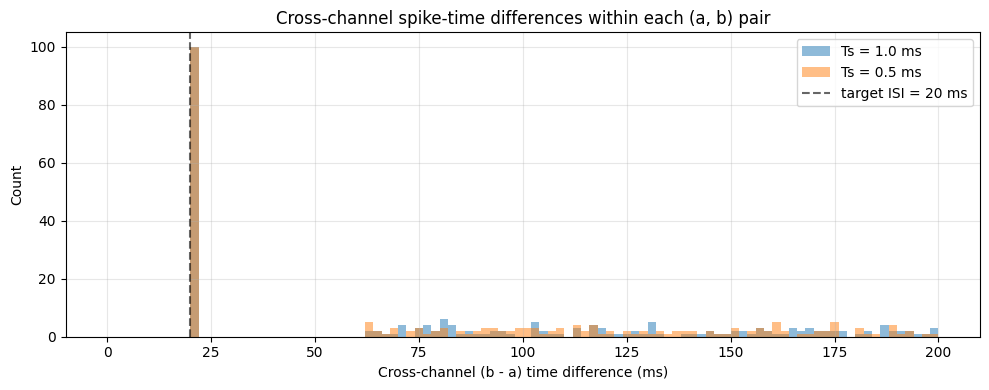


OK: cross-channel ISI structure is preserved at both Ts.


In [5]:
def cross_pair_diffs_ms(train: np.ndarray, ts_ms: float) -> np.ndarray:
    """For each `(neuron_a, neuron_b)` pair, return positive (b - a) time differences in ms."""
    out = []
    for pair_idx in range(0, train.shape[0], 2):
        a_times = np.where(train[pair_idx]     > 0)[0] * ts_ms
        b_times = np.where(train[pair_idx + 1] > 0)[0] * ts_ms
        if len(a_times) == 0 or len(b_times) == 0:
            continue
        diffs = b_times[:, None] - a_times[None, :]
        out.append(diffs[diffs > 0])
    return np.concatenate(out) if out else np.array([])


ccd_1ms  = cross_pair_diffs_ms(train_1ms,  ts_ms=1.0)
ccd_05ms = cross_pair_diffs_ms(train_05ms, ts_ms=0.5)

exact_1ms  = int(np.sum(ccd_1ms  == ISI))
exact_05ms = int(np.sum(ccd_05ms == ISI))
expected_cross_pair_diffs = (NUM_NEURONS // 2) * round(FIRING_RATE * 1.0)

print(f'Number of cross-channel (b - a) diffs landing exactly at {ISI} ms:')
print(f'  Ts = 1.0 ms:  {exact_1ms:>4d}')
print(f'  Ts = 0.5 ms:  {exact_05ms:>4d}')
print(f'  Expected (one per CCISI pair placement): {expected_cross_pair_diffs}')

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.arange(0, 200 + 2, 2)
ax.hist(ccd_1ms,  bins=bins, alpha=0.5, label='Ts = 1.0 ms', color='tab:blue')
ax.hist(ccd_05ms, bins=bins, alpha=0.5, label='Ts = 0.5 ms', color='tab:orange')
ax.axvline(ISI, color='k', linestyle='--', alpha=0.6, label=f'target ISI = {ISI} ms')
ax.set_xlabel('Cross-channel (b - a) time difference (ms)')
ax.set_ylabel('Count')
ax.set_title('Cross-channel spike-time differences within each (a, b) pair')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

assert exact_1ms  >= expected_cross_pair_diffs, 'fewer cross-pair diffs than expected at Ts=1ms'
assert exact_05ms >= expected_cross_pair_diffs, 'fewer cross-pair diffs than expected at Ts=0.5ms'
print('\nOK: cross-channel ISI structure is preserved at both Ts.')

## 6. Test 5: sweep over `(firing_rate, isi)`

Run the comparison across the parameter range used by the actual dataset
(`firing_rate` in {2, 4, 6, 8, 10} Hz, `isi` in {1, 5, 10, 20, 50} ms) and
report any case where the spike counts disagree.

**Expected:** counts are exactly equal except in dense corners (high rate +
long ISI) where the random placement loop hits `MAX_PLACEMENT_ATTEMPTS`
without finding a conflict-free slot. In those cases, both implementations
*will* differ by a few spikes because their random call sequences see
different upper bounds for `np.random.randint(0, T - isi_steps)`. This is
an inherent randomness artefact, not a bug.

In [6]:
FIRING_RATES = [2, 4, 6, 8, 10]
ISIS         = [1, 5, 10, 20, 50]

print(f"{'rate':>5s}  {'isi':>4s}  {'expected':>9s}  {'count_1ms':>10s}  {'count_05ms':>11s}  {'note':>20s}")
print('-' * 70)
saturated_cases = 0
for rate in FIRING_RATES:
    for isi in ISIS:
        np.random.seed(0)
        a = ccisi_1ms.generate_spike_train(
            firing_rate=rate, isi=isi, num_neurons=20, time_steps=1000,
        )
        np.random.seed(0)
        b = ccisi_05ms.generate_spike_train(
            firing_rate=rate, isi=isi, num_neurons=20, time_steps=2000, ts_ms=0.5,
        )
        expected = 20 * round(rate * 1.0)   # NUM_NEURONS * num_pairs (1 spike per neuron per pair)
        ca, cb   = int(a.sum()), int(b.sum())
        if ca == cb == expected:
            note = 'exact match'
        elif ca == cb:
            note = 'both saturated (=)'
            saturated_cases += 1
        else:
            note = f'saturated, diff={cb-ca:+d}'
            saturated_cases += 1
        print(f'{rate:>5d}  {isi:>4d}  {expected:>9d}  {ca:>10d}  {cb:>11d}  {note:>20s}')

print(f'\nSaturated cases (placement failures): {saturated_cases} / {len(FIRING_RATES)*len(ISIS)}')
print('In saturated cases, small Ts-dependent differences are expected — the')
print('two implementations draw from `np.random` with different upper bounds.')

 rate   isi   expected   count_1ms   count_05ms                  note
----------------------------------------------------------------------
    2     1         40          40           40           exact match
    2     5         40          40           40           exact match
    2    10         40          40           40           exact match
    2    20         40          40           40           exact match
    2    50         40          40           40           exact match
    4     1         80          80           80           exact match
    4     5         80          80           80           exact match
    4    10         80          80           80           exact match
    4    20         80          80           80           exact match
    4    50         80          80           80           exact match
    6     1        120         120          120           exact match
    6     5        120         120          120           exact match
    6    10        

## 7. Summary

Tests 1, 2, 4, and the non-saturated rows of test 5 confirm that the
0.5 ms version of `ccisi_data_gen.py` produces spike trains equivalent to
the 1 ms version in continuous time:

- **Same spike count** (test 1 and 5 non-saturated rows).
- **More zero bins, same nonzero bins** (test 2).
- **Same cross-channel ISI structure in real time** (test 4).

What you don't get is bit-for-bit reproducibility — the random placement
draws from `np.random` with different argument ranges at the two Ts, so the
exact spike positions vary. That's expected and isn't a bug; the only
downstream consequence is that the actual `.h5` files on disk for Ts=1 and
Ts=0.5 contain different spike placements even though they encode the same
`(firing_rate, ISI)` pairs.